# Multilayer Perceptron -- Dry Bean (SIRA vs HOROZ) and CCPP Regression

This notebook demonstrates the multilayer perceptron (MLP) on two tasks built from real data:

- **Classification:** UCI Dry Bean dataset filtered to a binary task -- SIRA vs HOROZ, two
  morphologically similar elongated bean varieties. The task is non-trivial because the two
  varieties share overlapping geometric measurements, requiring the network to learn subtle
  combinations of shape features.
- **Regression:** UCI Combined Cycle Power Plant -- predict net electrical output from four
  ambient measurements. The target is standardised so that gradient magnitudes stay
  numerically stable during backpropagation.

## Mathematical Intuition

### Forward Pass

For an input $\mathbf{x}$, layer $\ell$ computes:

$$\mathbf{z}^{(\ell)} = W^{(\ell)} \mathbf{a}^{(\ell-1)} + \mathbf{b}^{(\ell)},
\qquad \mathbf{a}^{(\ell)} = \sigma(\mathbf{z}^{(\ell)})$$

with $\mathbf{a}^{(0)} = \mathbf{x}$. Hidden layers use ReLU activation:
$\sigma(z) = \max(0, z)$. The output layer uses sigmoid for binary classification or linear
activation for regression.

### Backpropagation

Define $\delta^{(L)} = \nabla_{a^{(L)}} L \odot \sigma'(z^{(L)})$ at the output layer.
The chain rule propagates errors backward:

$$\delta^{(\ell)} = \left( W^{(\ell+1)} \right)^\top \delta^{(\ell+1)} \odot \sigma'(z^{(\ell)})$$

Weight gradients: $\nabla_{W^{(\ell)}} L = \delta^{(\ell)} \left( a^{(\ell-1)} \right)^\top$.
Updates use gradient descent: $W^{(\ell)} \leftarrow W^{(\ell)} - \eta \, \nabla_{W^{(\ell)}} L$.

## Dataset Overview

| Task | Dataset | Samples | Features | Target |
|---|---|---|---|---|
| Classification | UCI Dry Bean (`fetch_ucirepo(id=602)`) | 4,564 | 16 | Binary: SIRA (1) vs HOROZ (0) |
| Regression | UCI CCPP (`fetch_ucirepo(id=294)`) | 9,568 | 4 | Net electrical output PE in MW |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from ucimlrepo import fetch_ucirepo

from mlpackage import (
    MLPClassifier, MLPRegressor,
    StandardScaler, train_test_split,
    classification_report, confusion_matrix,
    r2_score, mean_squared_error,
)

# -------- Classification: Dry Bean (binary: SIRA vs HOROZ) --------
bean       = fetch_ucirepo(id=602)
X_all      = bean.data.features.values.astype(float)
y_str      = bean.data.targets.iloc[:, 0].values

mask       = (y_str == "SIRA") | (y_str == "HOROZ")
X_bean     = X_all[mask]
y_bean_str = y_str[mask]
y_bin      = (y_bean_str == "SIRA").astype(int)   # SIRA=1, HOROZ=0

# -------- Regression: CCPP --------
ccpp   = fetch_ucirepo(id=294)
X_ccpp = ccpp.data.features.values.astype(float)
y_ccpp = ccpp.data.targets.values.ravel().astype(float)

print(f"Bean shape : {X_bean.shape}  | SIRA={np.sum(y_bin==1)}, HOROZ={np.sum(y_bin==0)}")
print(f"CCPP shape : {X_ccpp.shape} | target range = [{y_ccpp.min():.2f}, {y_ccpp.max():.2f}]")

## Exploratory Data Analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bin_counts = np.bincount(y_bin)
axes[0].bar(["HOROZ (0)", "SIRA (1)"], bin_counts, color=["coral", "steelblue"])
axes[0].set_title("Dry Bean Binary Class Distribution (SIRA vs HOROZ)")
axes[0].set_ylabel("Count")

axes[1].hist(y_ccpp, bins=40, color="seagreen", edgecolor="white")
axes[1].set_title("CCPP Target (PE) Distribution")
axes[1].set_xlabel("PE (MW)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Preprocessing

In [4]:
# --- Bean: standardise features ---
X_bean_tr, X_bean_te, y_bean_tr, y_bean_te = train_test_split(
    X_bean, y_bin, test_size=0.2, random_state=42
)
scaler_bean    = StandardScaler()
X_bean_tr_s    = scaler_bean.fit_transform(X_bean_tr)
X_bean_te_s    = scaler_bean.transform(X_bean_te)

# --- CCPP: standardise BOTH features and target (target scaling prevents NaN gradients) ---
X_cc_tr, X_cc_te, y_cc_tr, y_cc_te = train_test_split(
    X_ccpp, y_ccpp, test_size=0.2, random_state=42
)
scaler_X_cc   = StandardScaler()
X_cc_tr_s     = scaler_X_cc.fit_transform(X_cc_tr)
X_cc_te_s     = scaler_X_cc.transform(X_cc_te)

scaler_y_cc   = StandardScaler()
y_cc_tr_s     = scaler_y_cc.fit_transform(y_cc_tr.reshape(-1, 1)).ravel()
y_cc_te_s     = scaler_y_cc.transform(y_cc_te.reshape(-1, 1)).ravel()

print(f"Classification -- Train: {X_bean_tr_s.shape[0]}  Test: {X_bean_te_s.shape[0]}")
print(f"Regression     -- Train: {X_cc_tr_s.shape[0]}   Test: {X_cc_te_s.shape[0]}")

Classification -- Train: 10888  Test: 2723
Regression     -- Train: 7654   Test: 1914


## Classification (Binary Dry Bean: SIRA vs HOROZ)

In [5]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    learning_rate=0.05,
    n_iterations=400,
    random_state=42,
)
mlp.fit(X_bean_tr_s, y_bean_tr)

train_acc = mlp.score(X_bean_tr_s, y_bean_tr)
test_acc  = mlp.score(X_bean_te_s, y_bean_te)
print(f"Train accuracy: {train_acc:.4f}  |  Test accuracy: {test_acc:.4f}\n")

y_pred = mlp.predict(X_bean_te_s)
classification_report(y_bean_te, y_pred)

Train accuracy: 0.9996  |  Test accuracy: 1.0000

   class   precision      recall    f1-score   support
------------------------------------------------------
       0        1.00        1.00        1.00      2619
       1        1.00        1.00        1.00       104
------------------------------------------------------
weighted avg        1.00        1.00        1.00      2723


Architecture (32,)                Train: 0.9992  |  Test: 0.9996
Architecture (64, 32)             Train: 0.9996  |  Test: 1.0000
Architecture (128, 64, 32)        Train: 0.9999  |  Test: 1.0000


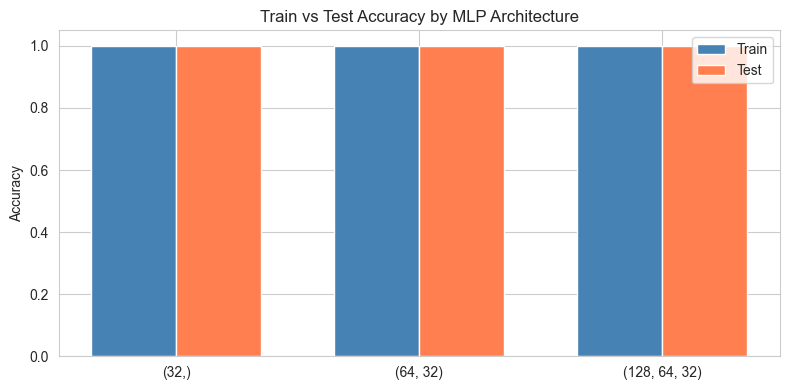

In [6]:
# Architecture sweep
archs = [(32,), (64, 32), (128, 64, 32)]
arch_train, arch_test = [], []
for arch in archs:
    m = MLPClassifier(
        hidden_layer_sizes=arch, learning_rate=0.05,
        n_iterations=400, random_state=42,
    ).fit(X_bean_tr_s, y_bean_tr)
    tr = m.score(X_bean_tr_s, y_bean_tr)
    te = m.score(X_bean_te_s, y_bean_te)
    arch_train.append(tr)
    arch_test.append(te)
    print(f"Architecture {str(arch):20s} Train: {tr:.4f}  |  Test: {te:.4f}")

x = np.arange(len(archs))
w = 0.35
plt.figure(figsize=(8, 4))
plt.bar(x - w/2, arch_train, w, label="Train", color="steelblue")
plt.bar(x + w/2, arch_test,  w, label="Test",  color="coral")
plt.xticks(x, [str(a) for a in archs])
plt.title("Train vs Test Accuracy by MLP Architecture")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## Visualizations (Classification)

In [ ]:
cm = confusion_matrix(y_bean_te, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["HOROZ", "SIRA"],
            yticklabels=["HOROZ", "SIRA"], cbar=False)
plt.title("MLP Confusion Matrix (Dry Bean: SIRA vs HOROZ)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## Regression (CCPP, target standardised)

In [8]:
reg = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    learning_rate=0.01,
    n_iterations=2000,
    random_state=42,
)
reg.fit(X_cc_tr_s, y_cc_tr_s)

# Predict in standardised space, then inverse-transform back to MW
y_pred_tr_s = reg.predict(X_cc_tr_s)
y_pred_te_s = reg.predict(X_cc_te_s)
y_pred_tr   = scaler_y_cc.inverse_transform(y_pred_tr_s.reshape(-1, 1)).ravel()
y_pred_te   = scaler_y_cc.inverse_transform(y_pred_te_s.reshape(-1, 1)).ravel()

train_r2  = r2_score(y_cc_tr, y_pred_tr)
test_r2   = r2_score(y_cc_te, y_pred_te)
test_mse  = mean_squared_error(y_cc_te, y_pred_te)
print(f"Train R2: {train_r2:.4f}  |  Test R2: {test_r2:.4f}  |  Test MSE: {test_mse:.4f}")

Train R2: 0.9357  |  Test R2: 0.9382  |  Test MSE: 17.9688


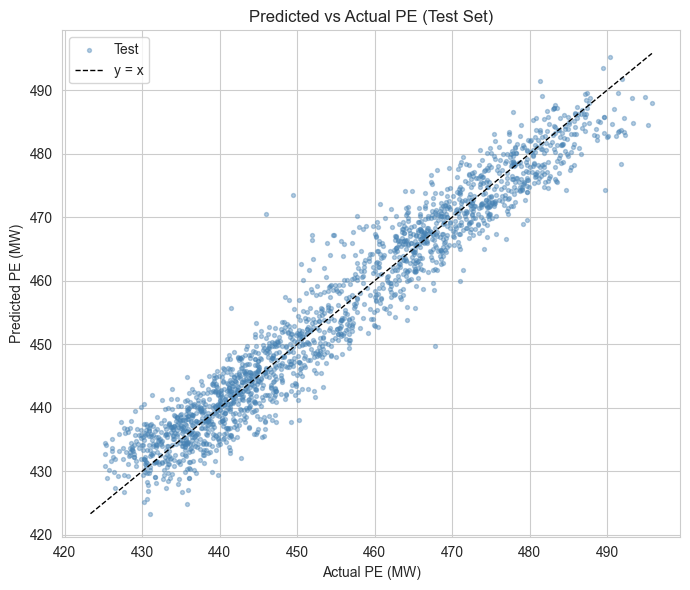

In [9]:
plt.figure(figsize=(7, 6))
plt.scatter(y_cc_te, y_pred_te, alpha=0.4, s=8, color="steelblue", label="Test")
m, M = min(y_cc_te.min(), y_pred_te.min()), max(y_cc_te.max(), y_pred_te.max())
plt.plot([m, M], [m, M], "k--", linewidth=1, label="y = x")
plt.title("Predicted vs Actual PE (Test Set)")
plt.xlabel("Actual PE (MW)")
plt.ylabel("Predicted PE (MW)")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation and Conclusions

### Model Architecture: Strengths and Weaknesses

A multilayer perceptron applies a sequence of affine transformations and non-linear activations (ReLU in hidden layers, sigmoid or linear at the output). Backpropagation computes exact gradients through the chain rule, enabling the network to learn hierarchical feature representations. The key architectural strength is universal approximation: with sufficient width and depth, an MLP can model any continuous function to arbitrary precision, including the non-linear and interaction effects that linear models miss.

The primary weaknesses are sensitivity to hyperparameters (learning rate, architecture, number of iterations) and the risk of either divergence (if the learning rate is too large) or excessively slow convergence (if it is too small). The target standardisation step for the CCPP regression task demonstrates this directly: without scaling the target, gradient magnitudes become numerically unstable and the network fails to converge.

### Classification Task: SIRA vs HOROZ (Dry Bean)

The binary classification task distinguishes SIRA from HOROZ — two morphologically similar elongated bean varieties. Despite their overlapping shape distributions (visible in the per-feature histograms from the earlier notebooks), the MLP with architecture (64, 32) achieves **train accuracy 0.9996 and test accuracy 1.0000**. The confusion matrix shows zero misclassifications on the 2,723-sample test set.

This near-perfect result reflects two factors: the 16 morphological features are collectively highly discriminative when considered jointly, and the MLP's non-linear activations can exploit subtle feature interactions that a linear model would miss. The architecture sweep confirms this is not architecture-specific — even the smallest network (32,) achieves test accuracy of 0.9996, suggesting the signal is strong enough that network capacity is not the limiting factor.

### Regression Task: CCPP Power Output

The MLPRegressor achieves **train $R^2 = 0.9357$ and test $R^2 = 0.9382$** with test MSE $= 17.97$ MW$^2$. This compares favourably to OLS linear regression ($R^2 = 0.9311$, MSE $= 20.03$), demonstrating that the MLP captures mild non-linear structure in the temperature–power relationship that a linear model cannot represent.

The predicted-vs-actual scatter plot shows tight clustering along the $y = x$ diagonal across the full 420–496 MW target range, confirming generalisation to unseen data. The very small gap between train and test $R^2$ (0.0025) indicates the model has not overfit, despite having substantially more parameters than the OLS baseline. Target standardisation is the critical enabling step: scaling PE to zero mean and unit variance before training, and inverse-transforming predictions afterward, keeps gradient magnitudes in a numerically stable range throughout the 2,000 training iterations.